# Part A - Concept Application

## EDA Report Notebook

## 1. Import Libraries

In [3]:
%pip install seaborn

     |████████████████████████████████| 294 kB 5.8 MB/s eta 0:00:01
You should consider upgrading via the '/Users/niranjanhebli/Desktop/Week3/week3/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### 2. Load Dataset

In [6]:
df = pd.read_csv("eda_assignment_data.csv")
df.head()

,CustomerID,Age,Income,SpendingScore,Gender,City,Membership,Transactions,Satisfaction,Churn
0,1001,56,25408,12,Female,Ahmedabad,Silver,46,3.97,No
1,1002,69,79379,3,Female,Bengaluru,Gold,23,4.22,No
2,1003,46,45053,18,Female,Bengaluru,Silver,32,4.38,Yes
3,1004,32,29446,40,Female,Bengaluru,Platinum,40,2.58,Yes
4,1005,60,20922,21,Male,Mumbai,Platinum,13,1.21,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     1200 non-null   int64  
 1   Age            1200 non-null   int64  
 2   Income         1200 non-null   int64  
 3   SpendingScore  1200 non-null   int64  
 4   Gender         1200 non-null   object 
 5   City           1200 non-null   object 
 6   Membership     1200 non-null   object 
 7   Transactions   1200 non-null   int64  
 8   Satisfaction   1200 non-null   float64
 9   Churn          1200 non-null   object 
dtypes: float64(1), int64(5), object(4)
memory usage: 93.9+ KB


In [8]:
df.describe(include='all')

,CustomerID,Age,Income,SpendingScore,Gender,City,Membership,Transactions,Satisfaction,Churn
count,1200.000000,1200.000000,1200.000000,1200.000000,1200,1200,1200,1200.000000,1200.000000,1200
unique,NaN,NaN,NaN,NaN,2,4,3,NaN,NaN,2
top,NaN,NaN,NaN,NaN,Male,Ahmedabad,Platinum,NaN,NaN,No
freq,NaN,NaN,NaN,NaN,623,321,416,NaN,NaN,609
mean,1600.500000,43.627500,85019.410833,48.370833,NaN,NaN,NaN,25.271667,2.994533,NaN
std,346.554469,15.052881,37796.240654,29.252089,NaN,NaN,NaN,13.990687,1.154347,NaN
min,1001.000000,18.000000,20060.000000,1.000000,NaN,NaN,NaN,1.000000,1.000000,NaN
25%,1300.750000,31.000000,51981.750000,22.000000,NaN,NaN,NaN,14.000000,1.990000,NaN
50%,1600.500000,44.000000,83982.500000,47.000000,NaN,NaN,NaN,25.000000,2.970000,NaN
75%,1900.250000,56.000000,117898.500000,74.000000,NaN,NaN,NaN,37.000000,3.975000,NaN


## 3. Distribution Plots (Histogram + KDE)


## Plot 1: Age Distribution

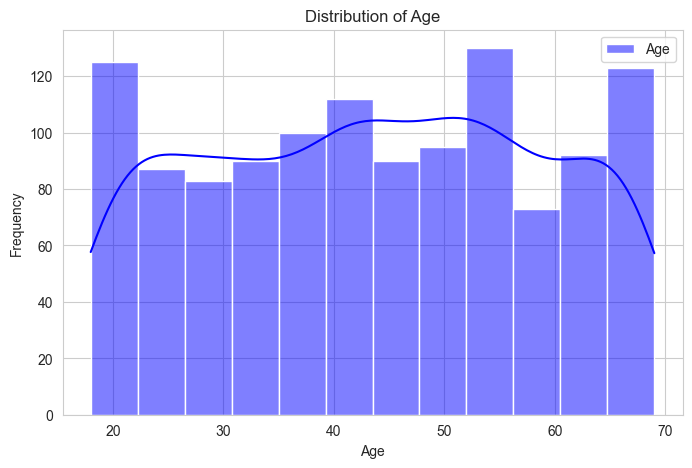

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True, label='Age', color='blue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Insight

The age distribution shows where most observations are concentrated and whether the feature is symmetric or skewed. A smooth KDE curve helps identify density peaks and possible age clusters.


## Plot 2: Income Distribution

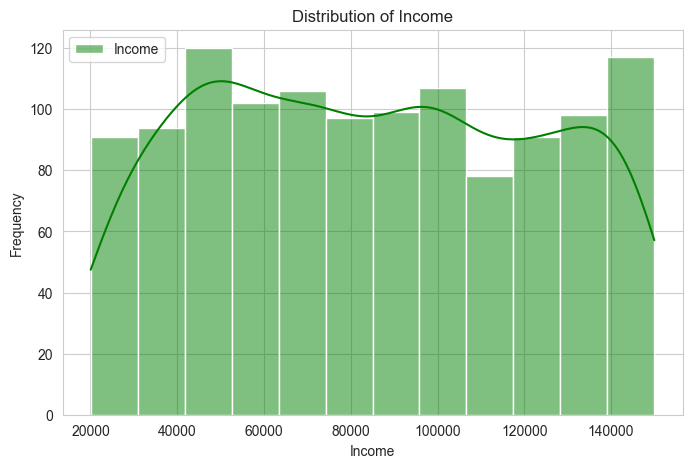

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Income'], kde=True, label='Income', color='green')
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Insight

Income often exhibits right skew because a small number of observations may have very high values. This suggests unequal spread and possible outliers in earnings.


## Plot 3: Spending Score Distribution

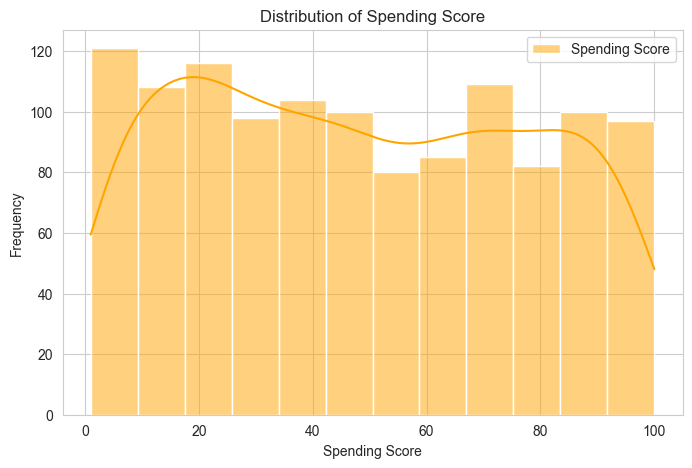

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['SpendingScore'], kde=True, label='Spending Score', color='orange')
plt.title('Distribution of Spending Score')
plt.xlabel('Spending Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Insight

The spending score distribution helps identify whether customer behavior is evenly spread or clustered. Multiple peaks may indicate distinct spending groups.


## 4. Relationship Plots (Scatter + Regression Line)

## Plot 4: Age vs Income

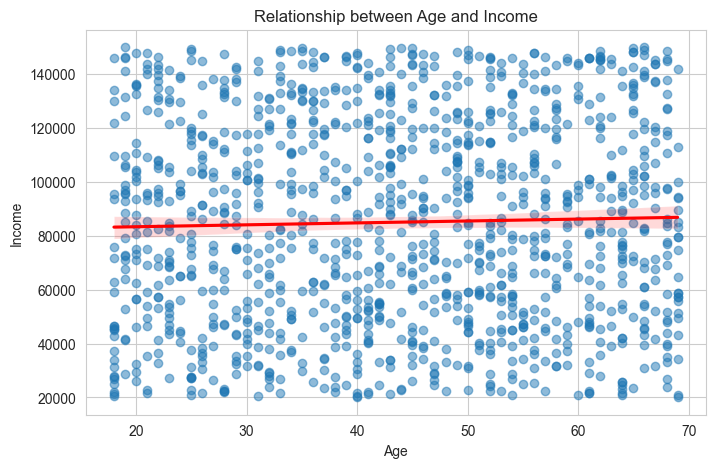

In [12]:
plt.figure(figsize=(8,5))
sns.regplot(x='Age', y='Income', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relationship between Age and Income')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

### Insight

The regression line shows whether income tends to increase or decrease with age. Scatter spread reveals how strong or weak the relationship is.


## Plot 5: Income vs Spending Score

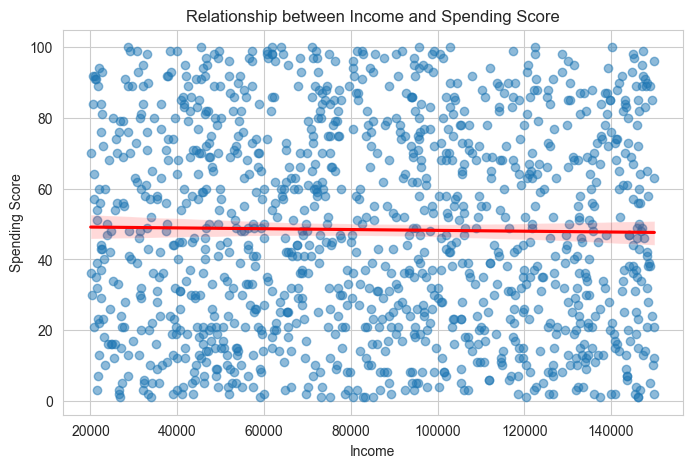

In [13]:
plt.figure(figsize=(8,5))
sns.regplot(x='Income', y='SpendingScore', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relationship between Income and Spending Score')
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.show()

### Insight

This plot helps evaluate whether higher income leads to higher spending behavior. A weak slope suggests other variables may influence spending more strongly.


## 5. Correlation Heatmap

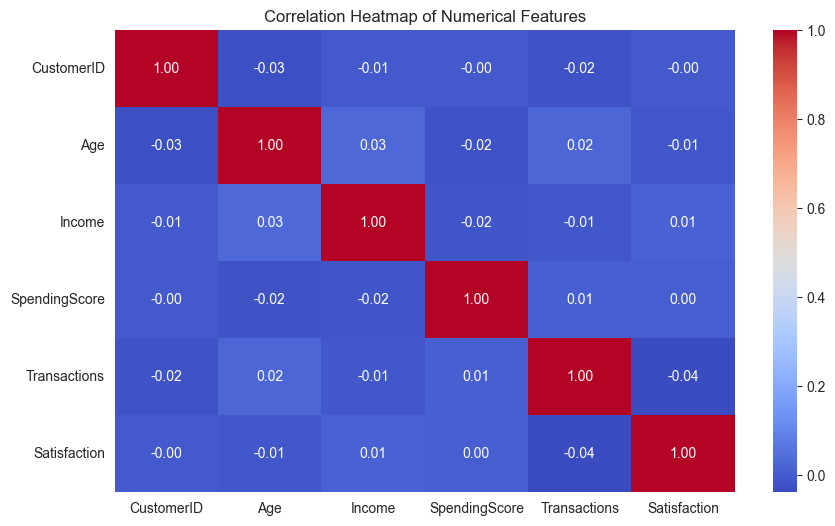

In [15]:
plt.figure(figsize=(10,6))

num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Insight

The heatmap highlights strong positive or negative correlations among numerical variables. Features with high correlation may provide overlapping information.

## 6. Box Plot Across Categories

## Spending Score across Gender

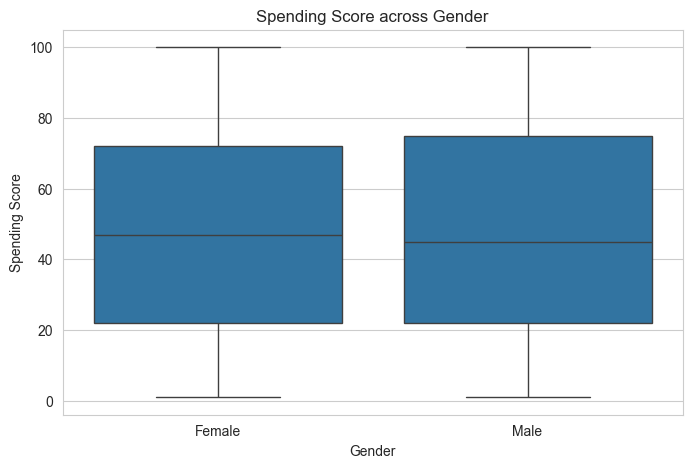

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Gender', y='SpendingScore', data=df)
plt.title('Spending Score across Gender')
plt.xlabel('Gender')
plt.ylabel('Spending Score')
plt.show()

### Insight

The box plot compares median spending and variability across categories. Outliers indicate unusually high or low values within a category.


## 7. Missing Values Check

In [17]:
df.isnull().sum()

CustomerID       0
Age              0
Income           0
SpendingScore    0
Gender           0
City             0
Membership       0
Transactions     0
Satisfaction     0
Churn            0
dtype: int64

## 8. Duplicate Rows Check

In [20]:
df.duplicated().sum()

np.int64(0)

# Part B :- Stretch Problem

In [21]:
import pandas as pd
df = pd.read_csv("eda_assignment_data.csv")

In [30]:
%pip install plotly
%pip install statsmodels
%pip install nbformat

811.61s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


You should consider upgrading via the '/Users/niranjanhebli/Desktop/Week3/week3/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


817.55s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


     |████████████████████████████████| 10.0 MB 4.3 MB/s eta 0:00:01
     |████████████████████████████████| 233 kB 1.0 MB/s eta 0:00:01
You should consider upgrading via the '/Users/niranjanhebli/Desktop/Week3/week3/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


827.58s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


     |████████████████████████████████| 78 kB 4.6 MB/s eta 0:00:01
     |████████████████████████████████| 90 kB 23.5 MB/s eta 0:00:01
     |████████████████████████████████| 67 kB 15.2 MB/s eta 0:00:01
     |████████████████████████████████| 354 kB 33.5 MB/s eta 0:00:01
You should consider upgrading via the '/Users/niranjanhebli/Desktop/Week3/week3/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## 1. Interactive Histogram

In [38]:
import plotly.express as px

fig = px.histogram(
    df,
    x='Age',


    nbins=30,
    title='Interactive Age Distribution',
    marginal='box'
)

fig.write_html('output/age_distribution.html')

## 2. Interactive Scatter with Regression Trend

In [39]:
fig = px.scatter(
    df,
    x='Income',
    y='SpendingScore',
    trendline='ols',
    title='Interactive Income vs Spending Score'
)

fig.write_html('output/income_spending_relationship.html')


## 3. Interactive Box Plot

In [40]:
fig = px.box(
    df,
    x='Membership',
    y='SpendingScore',
    title='Interactive Spending Score across Membership'
)


fig.write_html('output/membership_boxplot.html')